# Taller LSTM – Parte 2: Diseño, entrenamiento y comparación de arquitecturas

**Problema:** con una ventana de *n* horas consecutivas (12, 24 o 48), predecir la demanda eléctrica de la **hora siguiente**.

**Entrada:** `data/energy_demand_clean.csv`, generado por `01_data_cleaning.ipynb`.

| Condición del taller | Dónde se cumple |
|---|---|
| No usar información futura como entrada | §2 (se excluye `demanda_objetivo`) y §5 (la ventana termina en *t*; el target es *t+1*; se verifica con `assert`) |
| Ordenar cronológicamente antes de crear secuencias | §1 (datos ordenados) y §5 |
| Split cronológico, sin `train_test_split` aleatorio | §3 (cortes por fecha) |
| Normalizar solo con parámetros de entrenamiento | §4 (`StandardScaler.fit` solo con filas de train) |
| Mínimo tres arquitecturas LSTM | §7 (A base, B profunda, C mayor capacidad + Dropout) |
| Ventanas de 12, 24 y 48 h | §8 |
| MAE, MSE, RMSE, MAPE, R² | §9 |
| Sobreajuste y generalización | §11 y §12 (Early Stopping y Dropout) |
| Gráficas pedidas | §10 |

In [1]:
import json
import os
import time
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras import layers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import lstm_pipeline as pipeline

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

SEED = 42
WINDOWS = [12, 24, 48]
MAX_EPOCHS = 100
BATCH_SIZE = 64
EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 1e-4
RETRAIN = False  # True = retrain everything; False = reuse saved models if they exist

MODELS_DIR = pipeline.MODELS_DIR
HISTORY_DIR = MODELS_DIR / "histories"
FIG_DIR = Path("outputs/figures")
REPORT_DIR = Path("outputs/reports")
for directory in (MODELS_DIR, HISTORY_DIR, FIG_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

COLOR_INK = "#0b0b0b"
COLOR_MUTED = "#8a8984"
ARCH_COLORS = {"A": "#2a78d6", "B": "#eb6834", "C": "#1baf7a"}
SPLIT_COLORS = {"train": "#2a78d6", "val": "#eb6834", "test": "#1baf7a"}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.6,
    "axes.edgecolor": COLOR_MUTED, "axes.titleweight": "bold", "lines.linewidth": 1.2,
})
print("Keras", keras.__version__, "| backend:", keras.backend.backend())

Keras 3.15.1 | backend: tensorflow


## 1. Carga de los datos limpios

In [2]:
data = pipeline.add_calendar_features(pipeline.load_clean_data())
assert data["timestamp"].is_monotonic_increasing and not data["timestamp"].duplicated().any()
print(f"{len(data):,} horas | {data['timestamp'].min()} → {data['timestamp'].max()}")
data.head()

17,520 horas | 2025-01-01 00:00:00 → 2026-12-31 23:00:00


,timestamp,demanda_mw,temperatura_c,humedad_pct,viento_kmh,radiacion_wm2,precipitacion_mm,precio_kwh,hora,dia_semana,fin_semana,festivo,mes,periodo_dia,demanda_objetivo,hora_sin,hora_cos,dia_sin,dia_cos,mes_sin,mes_cos
0,2025-01-01 00:00:00,499.95,14.30,100.00,11.66,0.0,0.00,19.9186,0,2,0,1,1,madrugada,495.48,0.000000,1.000000,0.974928,-0.222521,0.0,1.0
1,2025-01-01 01:00:00,495.48,11.71,94.88,11.57,0.0,5.47,14.7994,1,2,0,1,1,madrugada,548.36,0.258819,0.965926,0.974928,-0.222521,0.0,1.0
2,2025-01-01 02:00:00,548.36,13.13,94.57,11.57,0.0,0.00,15.9562,2,2,0,1,1,madrugada,499.43,0.500000,0.866025,0.974928,-0.222521,0.0,1.0
3,2025-01-01 03:00:00,499.43,12.47,91.36,12.88,0.0,1.68,17.5124,3,2,0,1,1,madrugada,535.66,0.707107,0.707107,0.974928,-0.222521,0.0,1.0
4,2025-01-01 04:00:00,535.66,7.87,86.22,11.62,0.0,0.00,14.4538,4,2,0,1,1,madrugada,501.84,0.866025,0.500000,0.974928,-0.222521,0.0,1.0


## 2. Variables de entrada

En cada paso de la ventana (horas *t−n+1 … t*) el modelo recibe **15 variables**:

| Grupo | Variables | Tratamiento |
|---|---|---|
| Demanda histórica | `demanda_mw` | estandarizada |
| Clima | `temperatura_c`, `humedad_pct`, `viento_kmh`, `radiacion_wm2`, `precipitacion_mm` | estandarizadas |
| Mercado | `precio_kwh` | estandarizada |
| Calendario binario | `fin_semana`, `festivo` | 0/1 |
| Calendario cíclico | `hora`, `dia_semana`, `mes` → seno y coseno | en [−1, 1] |

**Decisiones justificadas:**

- **`demanda_objetivo` NO es entrada:** en la limpieza se verificó que `demanda_objetivo(t) = demanda_mw(t+1)`; usarla como entrada sería darle al modelo la respuesta (fuga de información futura). Es solo el **target**.
- **Codificación seno/coseno:** con `hora` como entero, 23 h y 0 h estarían "lejos" (23 vs 0) aunque son horas contiguas. Con (sen, cos) quedan juntas en un círculo. Lo mismo para día de la semana y mes.
- **`periodo_dia` no se usa:** es una función determinista de `hora` (0–5, 6–11, 12–17, 18–23), ya contenida en la codificación cíclica de la hora; añadirla no aporta información nueva.

In [3]:
print("Variables de entrada:", pipeline.FEATURE_COLS)
print("Número de variables:", len(pipeline.FEATURE_COLS))
assert pipeline.TARGET_COL not in pipeline.FEATURE_COLS

Variables de entrada: ['demanda_mw', 'temperatura_c', 'humedad_pct', 'viento_kmh', 'radiacion_wm2', 'precipitacion_mm', 'precio_kwh', 'fin_semana', 'festivo', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos']
Número de variables: 15


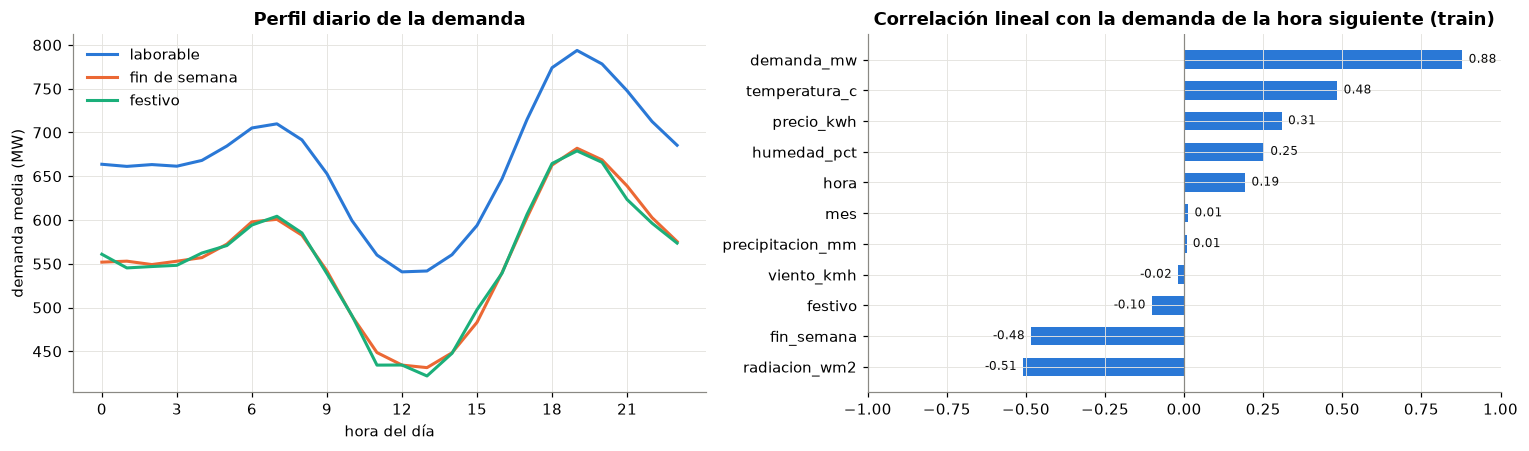

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
day_type = np.select([data["festivo"] == 1, data["fin_semana"] == 1], ["festivo", "fin de semana"], "laborable")
profile = data.assign(tipo_dia=day_type).groupby(["hora", "tipo_dia"])["demanda_mw"].mean().unstack()
for (label, color) in zip(["laborable", "fin de semana", "festivo"], ARCH_COLORS.values()):
    axes[0].plot(profile.index, profile[label], color=color, linewidth=2, label=label)
axes[0].set_xlabel("hora del día")
axes[0].set_ylabel("demanda media (MW)")
axes[0].set_title("Perfil diario de la demanda")
axes[0].set_xticks(range(0, 24, 3))
axes[0].legend(frameon=False)

train_period = data["timestamp"] < pipeline.VAL_START
correlations = (data.loc[train_period, pipeline.CONTINUOUS_COLS + pipeline.BINARY_COLS + ["hora", "mes"]]
                .corrwith(data.loc[train_period, pipeline.TARGET_COL]).sort_values())
axes[1].barh(correlations.index, correlations.values, color=ARCH_COLORS["A"], height=0.6)
axes[1].axvline(0, color=COLOR_MUTED, linewidth=0.8)
for y_pos, value in enumerate(correlations.values):
    axes[1].text(value + (0.02 if value >= 0 else -0.02), y_pos, f"{value:.2f}", va="center",
                 ha="left" if value >= 0 else "right", fontsize=8, color=COLOR_INK)
axes[1].set_xlim(-1, 1)
axes[1].set_title("Correlación lineal con la demanda de la hora siguiente (train)")
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_profile_correlation.png", bbox_inches="tight")
plt.show()

## 3. División cronológica entrenamiento / validación / prueba

Cada muestra se asigna según la **hora que se predice** (*t+1*), con cortes por fecha (nada aleatorio):

| Conjunto | Horas predichas | Uso |
|---|---|---|
| Entrenamiento | 2025-01-01 → 2026-06-30 (18 meses) | ajustar pesos y parámetros de normalización |
| Validación | 2026-07-01 → 2026-09-30 (3 meses) | early stopping, ajuste de learning rate, elegir modelo |
| Prueba | 2026-10-01 → 2026-12-31 (3 meses) | evaluación final, una sola vez |

**Justificación:** en una serie temporal un split aleatorio mezclaría horas futuras en el entrenamiento y el modelo "vería el futuro" (por ejemplo, entrenaría con el martes y se evaluaría con el lunes anterior). Con cortes cronológicos se simula el uso real: entrenar con el pasado y predecir lo que viene. El entrenamiento incluye un año completo y medio, por lo que el modelo ve todas las estaciones al menos una vez.

Las primeras ventanas de validación y prueba toman como **entrada** horas del periodo anterior: eso no es fuga, porque esas horas son pasado respecto a la hora que se predice.

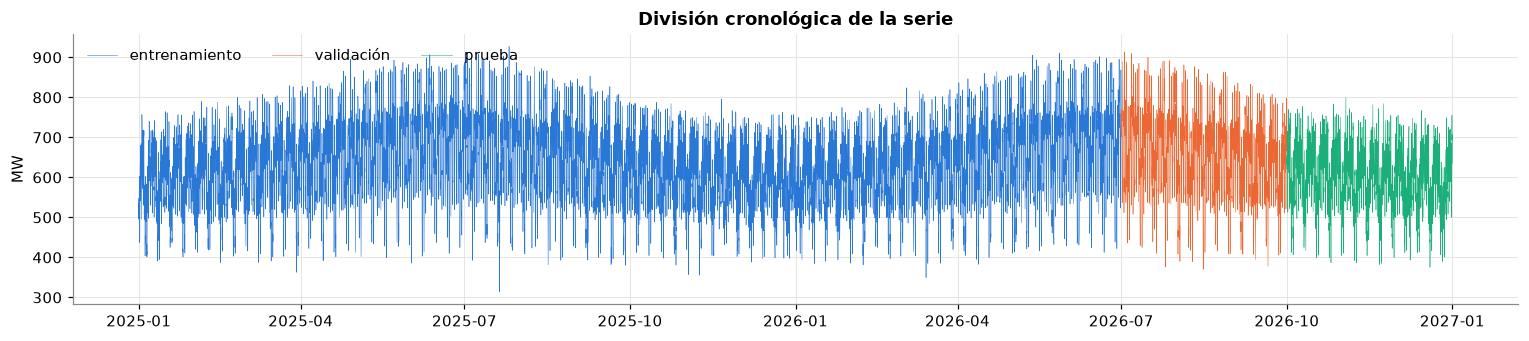

In [5]:
fig, ax = plt.subplots(figsize=(14, 3.2))
for split_name, (start, end) in {"train": (None, pipeline.VAL_START), "val": (pipeline.VAL_START, pipeline.TEST_START),
                                 "test": (pipeline.TEST_START, None)}.items():
    in_split = pd.Series(True, index=data.index)
    if start is not None:
        in_split &= data["timestamp"] >= start
    if end is not None:
        in_split &= data["timestamp"] < end
    ax.plot(data.loc[in_split, "timestamp"], data.loc[in_split, "demanda_mw"], color=SPLIT_COLORS[split_name],
            linewidth=0.35, label={"train": "entrenamiento", "val": "validación", "test": "prueba"}[split_name])
ax.set_ylabel("MW")
ax.set_title("División cronológica de la serie")
ax.legend(frameon=False, loc="upper left", ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / "split_timeline.png", bbox_inches="tight")
plt.show()

## 4. Normalización con parámetros de entrenamiento

Se usa `StandardScaler` (media 0, desviación 1). **El `fit` se hace solo con las filas del periodo de entrenamiento**; validación y prueba se transforman con esos mismos parámetros. Si se usara todo el dataset, la media y desviación incluirían información del futuro (fuga sutil).

El target también se estandariza (con su propio scaler, ajustado con los targets de entrenamiento) para que la pérdida MSE esté en una escala estable; las métricas finales se reportan en **MW** tras invertir la transformación.

In [6]:
train_rows = data["timestamp"] < pipeline.VAL_START
feature_scaler = StandardScaler().fit(data.loc[train_rows, pipeline.CONTINUOUS_COLS])

target_values = data[pipeline.TARGET_COL].to_numpy(dtype="float64")
target_times = (data["timestamp"] + pd.Timedelta(hours=1)).to_numpy()
train_targets = (target_times < np.datetime64(pipeline.VAL_START)) & ~np.isnan(target_values)
target_scaler = StandardScaler().fit(target_values[train_targets].reshape(-1, 1))

feature_matrix = pipeline.scale_features(data, feature_scaler)
scaled_targets = target_scaler.transform(target_values.reshape(-1, 1)).ravel().astype("float32")

pd.DataFrame({"media_train": feature_scaler.mean_, "desv_train": feature_scaler.scale_},
             index=pipeline.CONTINUOUS_COLS).round(3)

,media_train,desv_train
demanda_mw,636.067,98.407
temperatura_c,19.265,5.680
humedad_pct,71.758,14.760
viento_kmh,10.951,4.096
radiacion_wm2,206.065,262.473
precipitacion_mm,0.940,2.065
precio_kwh,24.667,5.329


## 5. Construcción de secuencias

Para cada hora *t*: **X** = las *n* filas *t−n+1 … t* (forma `n × 15`) y **y** = `demanda_objetivo(t)` = demanda de *t+1*.

Se verifica que (1) la última hora de cada ventana es anterior a la hora predicha, y (2) el conjunto de prueba contiene **exactamente las mismas horas** para las tres ventanas, para que la comparación 12/24/48 sea justa.

In [7]:
row_numbers = np.arange(len(data), dtype="float32").reshape(-1, 1)
row_timestamps = data["timestamp"].to_numpy()
one_hour = np.timedelta64(1, "h")

datasets = {}
for window in WINDOWS:
    X, y, times = pipeline.build_sequences(feature_matrix, scaled_targets, target_times, window)
    train_mask, val_mask, test_mask = pipeline.split_masks(times)

    # Leakage check: rebuild the windows over row numbers to recover the timestamp of every input hour.
    window_rows, _, _ = pipeline.build_sequences(row_numbers, scaled_targets, target_times, window)
    input_times = row_timestamps[window_rows[:, :, 0].astype(int)]
    assert (input_times.max(axis=1) < times).all(), "una ventana contiene la hora que se predice o posteriores"
    assert (input_times[:, -1] + one_hour == times).all(), "la ventana no termina justo antes de la hora predicha"
    assert (np.diff(input_times, axis=1) == one_hour).all(), "la ventana tiene horas no consecutivas"

    datasets[window] = {
        "X_train": X[train_mask], "y_train": y[train_mask],
        "X_val": X[val_mask], "y_val": y[val_mask],
        "X_test": X[test_mask], "y_test": y[test_mask],
        "t_train": times[train_mask], "t_val": times[val_mask], "t_test": times[test_mask],
    }

for window in WINDOWS[1:]:
    assert np.array_equal(datasets[window]["t_test"], datasets[WINDOWS[0]]["t_test"])

pd.DataFrame({
    f"{window} h": {
        "forma X_train": datasets[window]["X_train"].shape,
        "muestras train": len(datasets[window]["y_train"]),
        "muestras val": len(datasets[window]["y_val"]),
        "muestras test": len(datasets[window]["y_test"]),
        "primera hora predicha (test)": pd.Timestamp(datasets[window]["t_test"][0]),
        "última hora predicha (test)": pd.Timestamp(datasets[window]["t_test"][-1]),
    } for window in WINDOWS
})

,12 h,24 h,48 h
forma X_train,"(13092, 12, 15)","(13080, 24, 15)","(13056, 48, 15)"
muestras train,13092,13080,13056
muestras val,2208,2208,2208
muestras test,2208,2208,2208
primera hora predicha (test),2026-10-01 00:00:00,2026-10-01 00:00:00,2026-10-01 00:00:00
última hora predicha (test),2026-12-31 23:00:00,2026-12-31 23:00:00,2026-12-31 23:00:00


## 6. Líneas base (sin aprendizaje)

Antes de entrenar redes conviene saber qué error se obtiene con reglas triviales. Una LSTM útil debe superarlas claramente.

- **Persistencia:** la demanda de *t+1* será igual a la de *t*.
- **Estacional diaria:** la demanda de *t+1* será igual a la de la misma hora del día anterior (*t+1−24*).

In [8]:
def to_mw(scaled_values):
    return target_scaler.inverse_transform(np.asarray(scaled_values).reshape(-1, 1)).ravel()


def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "R2": r2_score(y_true, y_pred),
    }


demand_by_time = pd.Series(data["demanda_mw"].to_numpy(), index=data["timestamp"])
test_times = pd.DatetimeIndex(datasets[24]["t_test"])
y_test_mw = to_mw(datasets[24]["y_test"])
baseline_predictions = {
    "Persistencia (t)": demand_by_time.reindex(test_times - pd.Timedelta(hours=1)).to_numpy(),
    "Estacional diaria (t+1-24h)": demand_by_time.reindex(test_times - pd.Timedelta(hours=24)).to_numpy(),
}
baseline_results = pd.DataFrame({name: regression_metrics(y_test_mw, pred)
                                 for name, pred in baseline_predictions.items()}).T
baseline_results.round(3)

,MAE,MSE,RMSE,MAPE,R2
Persistencia (t),35.297,1956.589,44.233,5.992,0.692
Estacional diaria (t+1-24h),51.395,4716.900,68.680,8.915,0.258


## 7. Diseño de las arquitecturas

Las tres arquitecturas usan únicamente capas **LSTM**, **Dense** y **Dropout**. Así las diferencias de desempeño se pueden atribuir a dos factores controlados: la **profundidad** (número de capas LSTM) y la **capacidad + regularización** (número de neuronas y Dropout).

### A. LSTM base
`LSTM(64) → Dense(1)`

Una sola capa recurrente de 64 unidades que resume toda la ventana en su último estado oculto, y una neurona de salida lineal (regresión). Es el punto de referencia: la arquitectura más simple que aprovecha la memoria de la LSTM. Tiene pocos parámetros, entrena rápido y tiene bajo riesgo de sobreajuste.

### B. LSTM profunda
`LSTM(64, return_sequences=True) → LSTM(32) → Dense(1)`

Dos capas LSTM apiladas. La primera devuelve su salida en **cada hora** de la ventana (`return_sequences=True`), de modo que la segunda recibe una secuencia y no un único vector. La idea es construir representaciones jerárquicas: la primera capa capta patrones hora a hora y la segunda combina esos patrones en estructuras más largas (la rampa de la mañana, el pico de la tarde). Permite evaluar si **más profundidad** mejora a la LSTM base.

### C. LSTM con mayor capacidad y regularización
`LSTM(128, return_sequences=True) → Dropout(0.2) → LSTM(64) → Dropout(0.2) → Dense(32, ReLU) → Dense(1)`

- **Mayor capacidad:** el doble de neuronas que B en cada capa recurrente (128 y 64) y una capa densa intermedia de 32 neuronas con ReLU, que combina de forma no lineal el resumen que entrega la LSTM antes de la salida.
- **Regularización con Dropout (0.2):** durante el entrenamiento apaga al azar el 20 % de las salidas de cada capa LSTM, lo que obliga a la red a no depender de neuronas concretas. Es necesario porque, al tener muchos más parámetros, este modelo es el que más riesgo tiene de memorizar el entrenamiento.
- Permite evaluar si **más neuronas, controladas con Dropout,** mejoran a las arquitecturas más pequeñas.

In [9]:
def build_lstm_base(window, n_features, units=64):
    inputs = keras.Input(shape=(window, n_features))
    x = layers.LSTM(units)(inputs)
    outputs = layers.Dense(1)(x)
    return keras.Model(inputs, outputs, name="lstm_base")


def build_lstm_deep(window, n_features):
    inputs = keras.Input(shape=(window, n_features))
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.LSTM(32)(x)
    outputs = layers.Dense(1)(x)
    return keras.Model(inputs, outputs, name="lstm_deep")


def build_lstm_regularized(window, n_features, dropout=0.2):
    inputs = keras.Input(shape=(window, n_features))
    x = layers.LSTM(128, return_sequences=True)(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1)(x)
    return keras.Model(inputs, outputs, name="lstm_regularized")


ARCHITECTURES = {
    "A": {"label": "A. LSTM base", "slug": "lstm_base", "builder": build_lstm_base},
    "B": {"label": "B. LSTM profunda", "slug": "lstm_deep", "builder": build_lstm_deep},
    "C": {"label": "C. LSTM capacidad + Dropout", "slug": "lstm_regularized", "builder": build_lstm_regularized},
}
N_FEATURES = len(pipeline.FEATURE_COLS)
for arch in ARCHITECTURES.values():
    arch["builder"](24, N_FEATURES).summary()

Model: "lstm_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "lstm_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 24, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 24, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,249 (489.25 KB)

 Trainable params: 125,249 (489.25 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Entrenamiento

Configuración común (para que la comparación sea justa):

- **Optimizador:** Adam, learning rate inicial 0.001. **Pérdida:** MSE sobre el target estandarizado.
- **Batch:** 64. **Máximo:** 100 épocas.
- **EarlyStopping** (paciencia 10 sobre `val_loss`, `restore_best_weights=True`): detiene el entrenamiento cuando la validación lleva 10 épocas sin mejorar y recupera los pesos de la mejor época.
- **Semilla fija** (42) para reproducibilidad.

Dentro del conjunto de entrenamiento, Keras baraja el **orden de las ventanas** en cada época. Esto no viola la condición de no usar splits aleatorios: cada ventana conserva su orden temporal interno y todas pertenecen al periodo de entrenamiento; lo que se prohíbe es mezclar periodos entre train, validación y prueba.

Los modelos entrenados se guardan en `models/`; con `RETRAIN = False` se reutilizan si ya existen.

In [10]:
def make_callbacks(use_early_stopping=True):
    if not use_early_stopping:
        return []
    return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
                                          min_delta=EARLY_STOPPING_MIN_DELTA, restore_best_weights=True, verbose=0)]


def early_stopping_trace(val_losses, patience=EARLY_STOPPING_PATIENCE, min_delta=EARLY_STOPPING_MIN_DELTA):
    """Replays the Keras EarlyStopping rule: returns (epoch whose weights are restored, epoch where it stops).

    An epoch only counts as "better" if it lowers val_loss by more than min_delta.
    """
    best_value, best_epoch, wait = np.inf, 1, 0
    for epoch, value in enumerate(val_losses, start=1):
        wait += 1
        if value < best_value - min_delta:
            best_value, best_epoch, wait = value, epoch, 0
        elif wait >= patience:
            return best_epoch, epoch
    return best_epoch, len(val_losses)


def train_or_load(run_name, build_model, window, epochs=MAX_EPOCHS, use_early_stopping=True):
    model_path = MODELS_DIR / f"{run_name}.keras"
    history_path = HISTORY_DIR / f"{run_name}.json"
    if model_path.exists() and history_path.exists() and not RETRAIN:
        return keras.models.load_model(model_path), json.loads(history_path.read_text())

    keras.utils.set_random_seed(SEED)
    split = datasets[window]
    model = build_model(window, N_FEATURES)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
    start = time.time()
    fit_result = model.fit(split["X_train"], split["y_train"], validation_data=(split["X_val"], split["y_val"]),
                           epochs=epochs, batch_size=BATCH_SIZE, callbacks=make_callbacks(use_early_stopping),
                           verbose=0)
    history = {key: [float(value) for value in values] for key, values in fit_result.history.items()}
    history["train_seconds"] = time.time() - start
    model.save(model_path)
    history_path.write_text(json.dumps(history))
    return model, history


models, histories = {}, {}
for arch_key, arch in ARCHITECTURES.items():
    for window in WINDOWS:
        run_name = f"{arch['slug']}_w{window}"
        models[(arch_key, window)], histories[(arch_key, window)] = train_or_load(run_name, arch["builder"], window)
        history = histories[(arch_key, window)]
        best_epoch = early_stopping_trace(history["val_loss"])[0]
        print(f"{arch['label']:<26} ventana {window:>2} h | épocas {len(history['loss']):>3} "
              f"(mejor {best_epoch:>3}) | val_loss {min(history['val_loss']):.4f} | {history['train_seconds']:.0f} s")

A. LSTM base               ventana 12 h | épocas  25 (mejor  15) | val_loss 0.0668 | 26 s
A. LSTM base               ventana 24 h | épocas  23 (mejor  13) | val_loss 0.0668 | 33 s
A. LSTM base               ventana 48 h | épocas  32 (mejor  22) | val_loss 0.0680 | 85 s
B. LSTM profunda           ventana 12 h | épocas  20 (mejor  10) | val_loss 0.0669 | 30 s


B. LSTM profunda           ventana 24 h | épocas  24 (mejor  14) | val_loss 0.0660 | 60 s
B. LSTM profunda           ventana 48 h | épocas  17 (mejor   7) | val_loss 0.0691 | 60 s
C. LSTM capacidad + Dropout ventana 12 h | épocas  27 (mejor  17) | val_loss 0.0674 | 60 s


C. LSTM capacidad + Dropout ventana 24 h | épocas  30 (mejor  20) | val_loss 0.0675 | 120 s
C. LSTM capacidad + Dropout ventana 48 h | épocas  26 (mejor  16) | val_loss 0.0693 | 176 s


## 9. Evaluación y tabla de resultados

Las métricas se calculan en **MW** (escala original). `Épocas` = épocas entrenadas antes de que actuara el early stopping; `Mejor época` = época cuyos pesos restauró el early stopping (la última que mejoró `val_loss` en más de 0.0001).

In [11]:
predictions = {}
evaluation_rows = []
for (arch_key, window), model in models.items():
    split = datasets[window]
    history = histories[(arch_key, window)]
    for subset in ("train", "val", "test"):
        y_true = to_mw(split[f"y_{subset}"])
        y_pred = to_mw(model.predict(split[f"X_{subset}"], batch_size=512, verbose=0))
        predictions[(arch_key, window, subset)] = (y_true, y_pred)
        evaluation_rows.append({
            "arch": arch_key, "Modelo": ARCHITECTURES[arch_key]["label"], "Ventana": window, "conjunto": subset,
            **regression_metrics(y_true, y_pred),
            "Épocas": len(history["loss"]), "Mejor época": early_stopping_trace(history["val_loss"])[0],
            "Parámetros": model.count_params(), "Tiempo (s)": history["train_seconds"],
        })
evaluation = pd.DataFrame(evaluation_rows)

results_table = (evaluation[evaluation["conjunto"] == "test"]
                 [["Modelo", "Ventana", "MAE", "MSE", "RMSE", "MAPE", "R2", "Épocas", "Mejor época", "Parámetros", "Tiempo (s)"]]
                 .rename(columns={"R2": "R²", "MAPE": "MAPE (%)"})
                 .sort_values(["Modelo", "Ventana"]).reset_index(drop=True))
results_table.to_csv(REPORT_DIR / "results_table_test.csv", index=False, encoding="utf-8")
evaluation.to_csv(REPORT_DIR / "evaluation_all_subsets.csv", index=False, encoding="utf-8")

print("TABLA DE RESULTADOS – conjunto de PRUEBA (oct–dic 2026)")
results_table.style.format({"MAE": "{:.2f}", "MSE": "{:.1f}", "RMSE": "{:.2f}", "MAPE (%)": "{:.2f}", "R²": "{:.4f}",
                            "Parámetros": "{:,}", "Tiempo (s)": "{:.0f}"}).hide(axis="index")

TABLA DE RESULTADOS – conjunto de PRUEBA (oct–dic 2026)


Modelo,Ventana,MAE,MSE,RMSE,MAPE (%),R²,Épocas,Mejor época,Parámetros,Tiempo (s)
A. LSTM base,12,19.84,616.3,24.83,3.39,0.9031,25,15,"20,545",26
A. LSTM base,24,19.75,615.3,24.81,3.38,0.9032,23,13,"20,545",33
A. LSTM base,48,20.21,642.8,25.35,3.47,0.8989,32,22,"20,545",85
B. LSTM profunda,12,20.10,637.2,25.24,3.44,0.8998,20,10,"32,929",30
B. LSTM profunda,24,19.59,609.3,24.68,3.36,0.9042,24,14,"32,929",60
B. LSTM profunda,48,20.57,687.5,26.22,3.54,0.8919,17,7,"32,929",60
C. LSTM capacidad + Dropout,12,19.63,613.4,24.77,3.37,0.9035,27,17,"125,249",60
C. LSTM capacidad + Dropout,24,20.17,635.4,25.21,3.45,0.9001,30,20,"125,249",120
C. LSTM capacidad + Dropout,48,20.50,673.8,25.96,3.54,0.8940,26,16,"125,249",176


In [12]:
validation_rmse = evaluation[evaluation["conjunto"] == "val"].set_index(["arch", "Ventana"])["RMSE"]
best_arch, best_window = validation_rmse.idxmin()
best_label = ARCHITECTURES[best_arch]["label"]
best_test = evaluation.query("arch == @best_arch and Ventana == @best_window and conjunto == 'test'").iloc[0]
print(f"Mejor modelo según VALIDACIÓN: {best_label}, ventana {best_window} h")
print(f"  En prueba → MAE {best_test['MAE']:.2f} MW | RMSE {best_test['RMSE']:.2f} MW | "
      f"MAPE {best_test['MAPE']:.2f} % | R² {best_test['R2']:.4f}")
print("\nLíneas base en prueba:")
print(baseline_results[["MAE", "RMSE", "MAPE", "R2"]].round(3).to_string())

Mejor modelo según VALIDACIÓN: B. LSTM profunda, ventana 24 h
  En prueba → MAE 19.59 MW | RMSE 24.68 MW | MAPE 3.36 % | R² 0.9042

Líneas base en prueba:
                                MAE    RMSE   MAPE     R2
Persistencia (t)             35.297  44.233  5.992  0.692
Estacional diaria (t+1-24h)  51.395  68.680  8.915  0.258


> El mejor modelo se elige con el **RMSE de validación**, no con el de prueba: si se eligiera mirando la prueba, ese conjunto dejaría de ser una evaluación independiente.

## 10. Gráficas

### 10.1 Loss de entrenamiento y validación

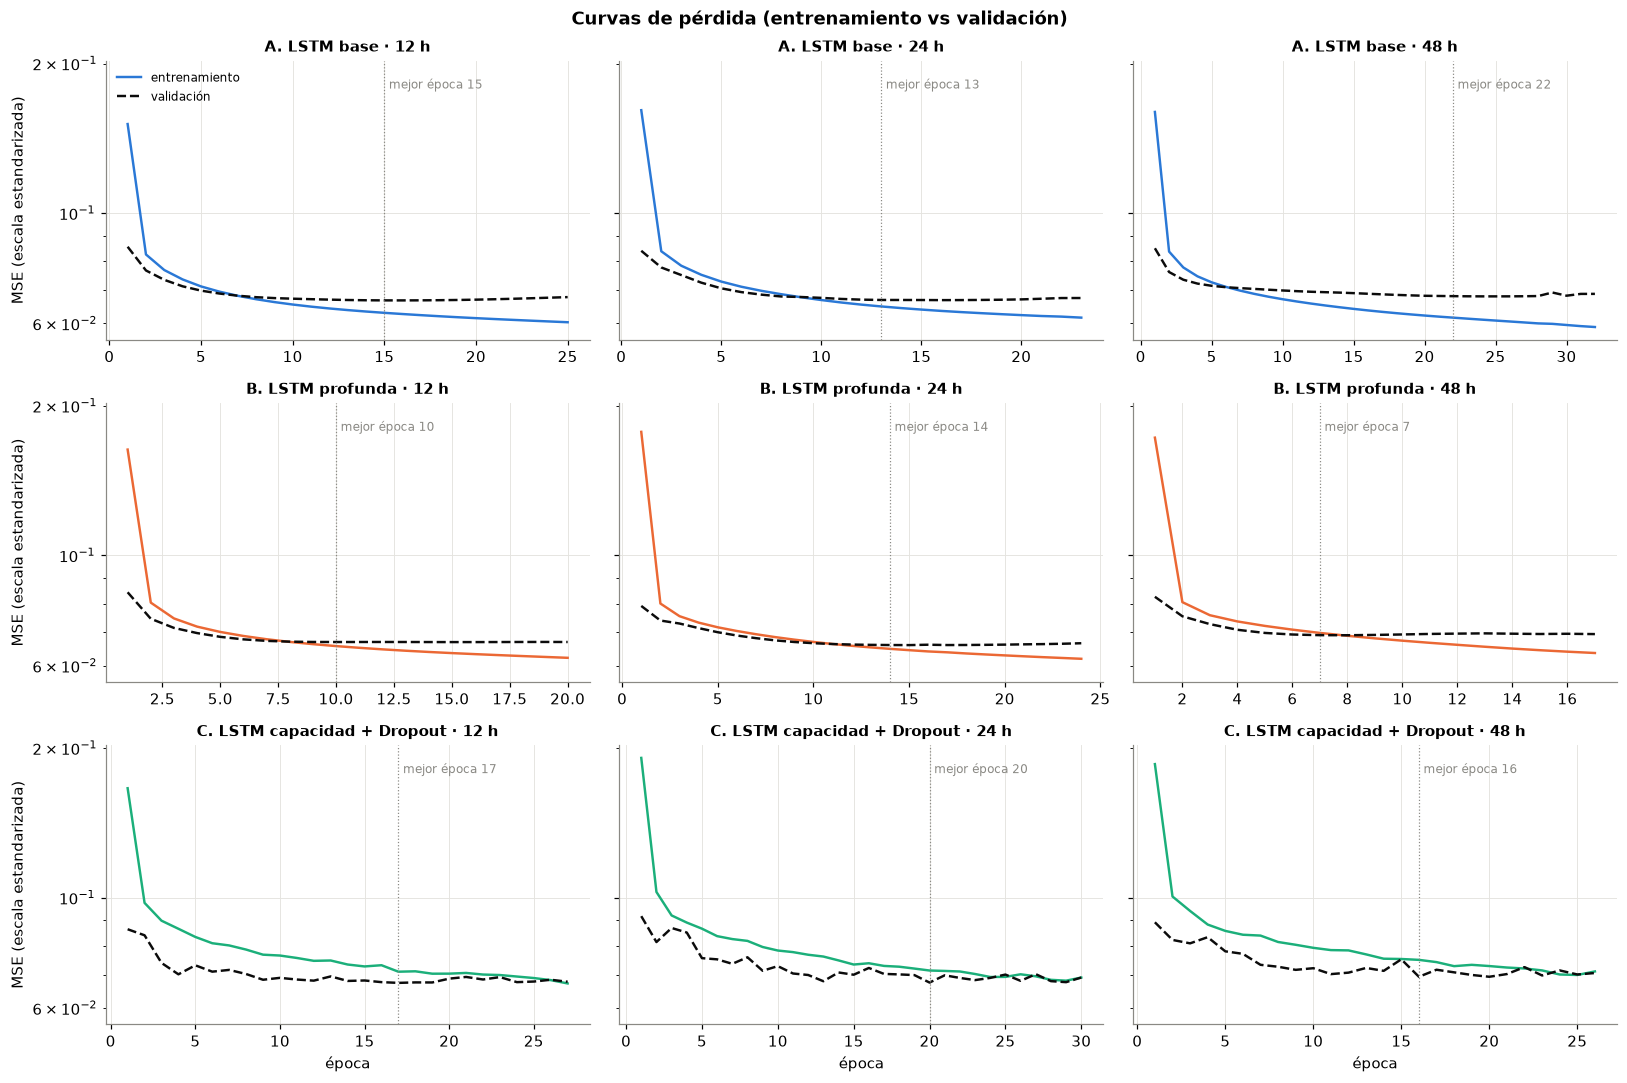

In [13]:
fig, axes = plt.subplots(len(ARCHITECTURES), len(WINDOWS), figsize=(15, 10), sharey=True)
for row, (arch_key, arch) in enumerate(ARCHITECTURES.items()):
    for col, window in enumerate(WINDOWS):
        ax = axes[row, col]
        history = histories[(arch_key, window)]
        epochs_axis = np.arange(1, len(history["loss"]) + 1)
        best_epoch = early_stopping_trace(history["val_loss"])[0]
        ax.plot(epochs_axis, history["loss"], color=ARCH_COLORS[arch_key], linewidth=1.6, label="entrenamiento")
        ax.plot(epochs_axis, history["val_loss"], color=COLOR_INK, linewidth=1.6, linestyle="--", label="validación")
        ax.axvline(best_epoch, color=COLOR_MUTED, linewidth=0.8, linestyle=":")
        ax.annotate(f"mejor época {best_epoch}", xy=(best_epoch, 0.9), xycoords=("data", "axes fraction"),
                    fontsize=8, color=COLOR_MUTED, ha="left", xytext=(3, 0), textcoords="offset points")
        ax.set_title(f"{arch['label']} · {window} h", fontsize=10)
        ax.set_yscale("log")
        if col == 0:
            ax.set_ylabel("MSE (escala estandarizada)")
        if row == len(ARCHITECTURES) - 1:
            ax.set_xlabel("época")
        if row == 0 and col == 0:
            ax.legend(frameon=False, fontsize=8)
fig.suptitle("Curvas de pérdida (entrenamiento vs validación)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "loss_curves.png", bbox_inches="tight")
plt.show()

### 10.2 Demanda real vs. predicha

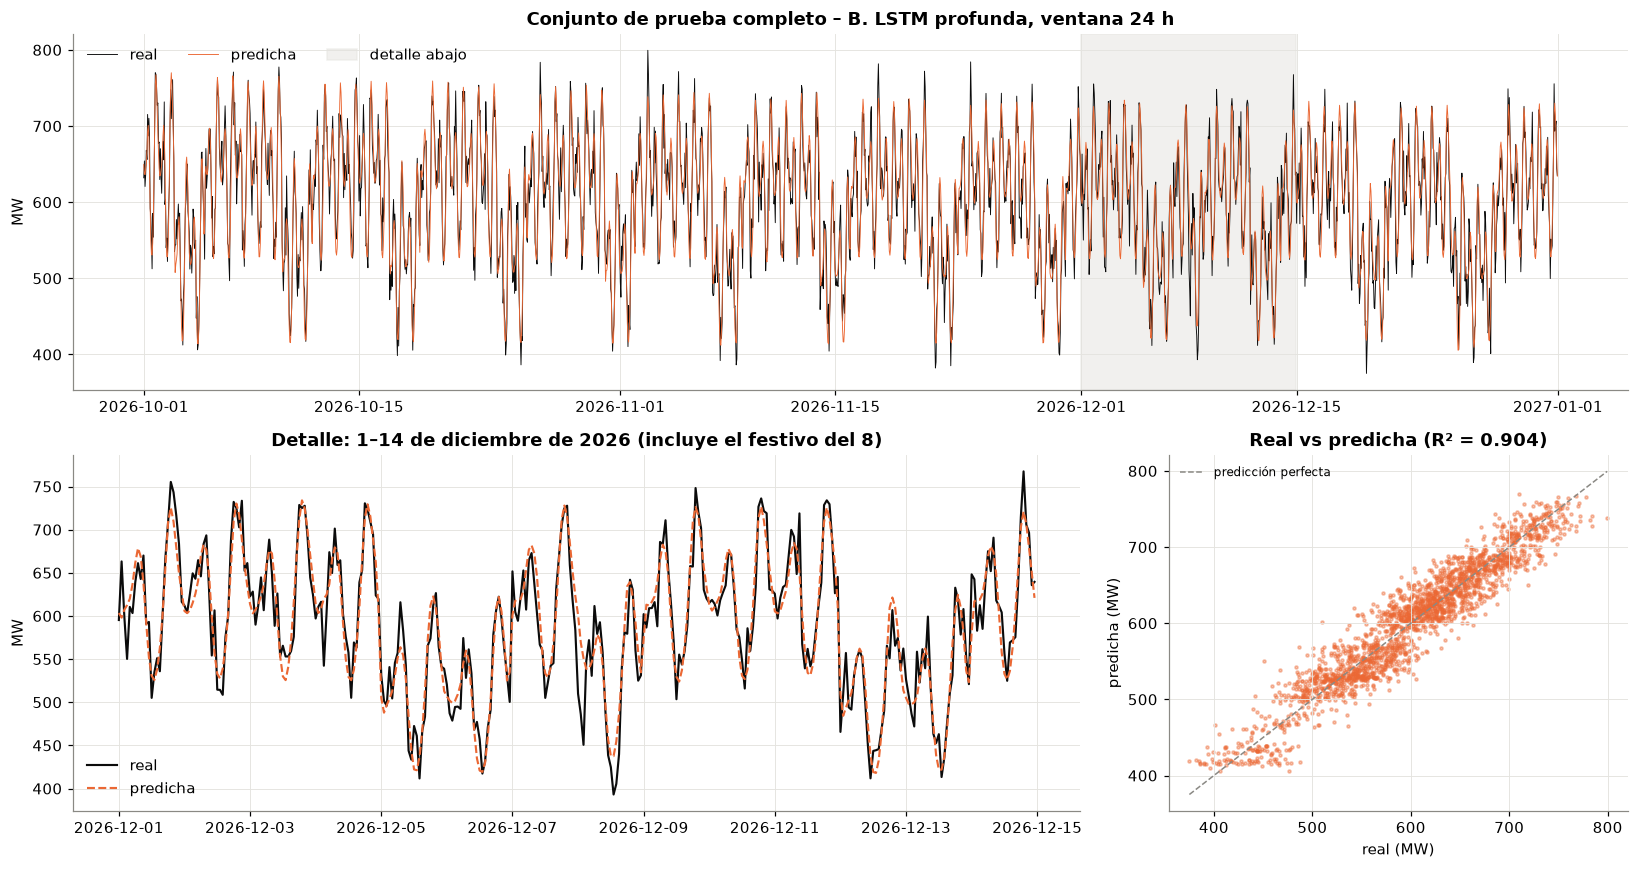

In [14]:
y_true_best, y_pred_best = predictions[(best_arch, best_window, "test")]
best_test_times = pd.DatetimeIndex(datasets[best_window]["t_test"])
zoom = (best_test_times >= "2026-12-01") & (best_test_times < "2026-12-15")

fig = plt.figure(figsize=(15, 8))
grid = fig.add_gridspec(2, 3)
ax_full = fig.add_subplot(grid[0, :])
ax_full.plot(best_test_times, y_true_best, color=COLOR_INK, linewidth=0.6, label="real")
ax_full.plot(best_test_times, y_pred_best, color=ARCH_COLORS[best_arch], linewidth=0.6, label="predicha")
ax_full.axvspan(best_test_times[zoom][0], best_test_times[zoom][-1], color="#e4e3df", alpha=0.5, label="detalle abajo")
ax_full.set_title(f"Conjunto de prueba completo – {best_label}, ventana {best_window} h")
ax_full.set_ylabel("MW")
ax_full.legend(frameon=False, ncol=3, loc="upper left")

ax_zoom = fig.add_subplot(grid[1, :2])
ax_zoom.plot(best_test_times[zoom], y_true_best[zoom], color=COLOR_INK, linewidth=1.4, label="real")
ax_zoom.plot(best_test_times[zoom], y_pred_best[zoom], color=ARCH_COLORS[best_arch], linewidth=1.4,
             linestyle="--", label="predicha")
ax_zoom.set_title("Detalle: 1–14 de diciembre de 2026 (incluye el festivo del 8)")
ax_zoom.set_ylabel("MW")
ax_zoom.legend(frameon=False)

ax_scatter = fig.add_subplot(grid[1, 2])
ax_scatter.scatter(y_true_best, y_pred_best, s=4, alpha=0.4, color=ARCH_COLORS[best_arch])
limits = [min(y_true_best.min(), y_pred_best.min()), max(y_true_best.max(), y_pred_best.max())]
ax_scatter.plot(limits, limits, color=COLOR_MUTED, linewidth=1, linestyle="--", label="predicción perfecta")
ax_scatter.set_xlabel("real (MW)")
ax_scatter.set_ylabel("predicha (MW)")
ax_scatter.set_title(f"Real vs predicha (R² = {best_test['R2']:.3f})")
ax_scatter.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "real_vs_predicted_best.png", bbox_inches="tight")
plt.show()

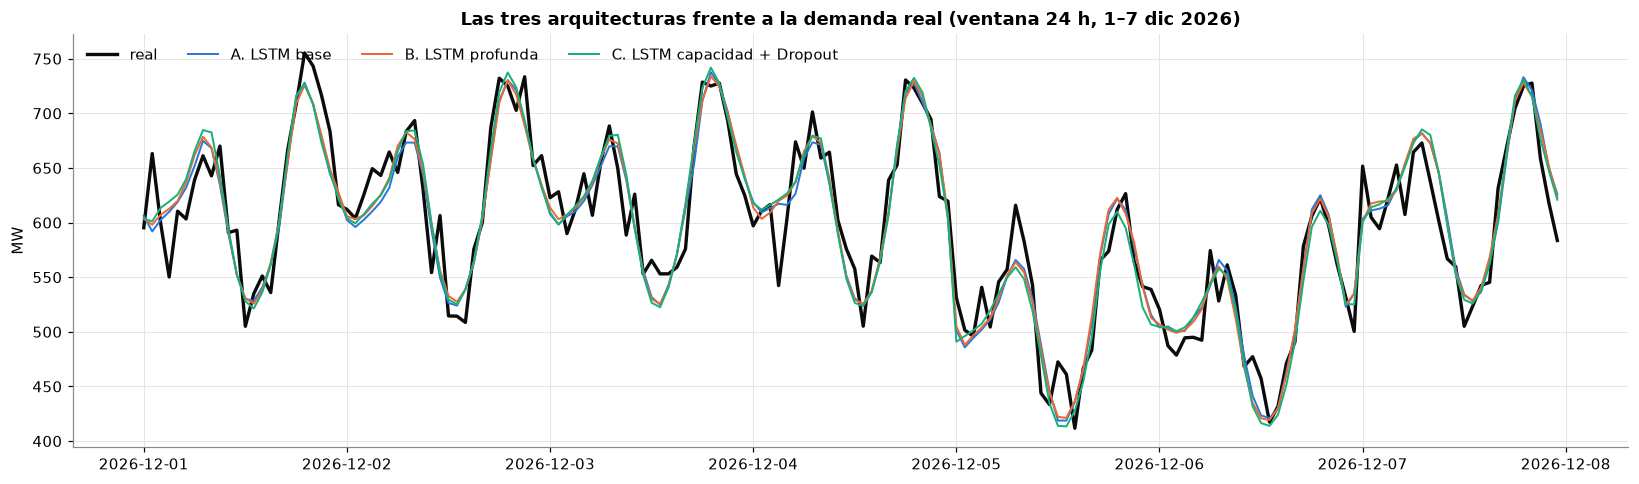

In [15]:
fig, ax = plt.subplots(figsize=(15, 4.5))
week = (best_test_times >= "2026-12-01") & (best_test_times < "2026-12-08")
y_true_week = predictions[(best_arch, best_window, "test")][0][week]
ax.plot(best_test_times[week], y_true_week, color=COLOR_INK, linewidth=2.2, label="real")
for arch_key, arch in ARCHITECTURES.items():
    _, y_pred_arch = predictions[(arch_key, best_window, "test")]
    ax.plot(best_test_times[week], y_pred_arch[week], color=ARCH_COLORS[arch_key], linewidth=1.3, label=arch["label"])
ax.set_ylabel("MW")
ax.set_title(f"Las tres arquitecturas frente a la demanda real (ventana {best_window} h, 1–7 dic 2026)")
ax.legend(frameon=False, ncol=4, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "real_vs_predicted_architectures.png", bbox_inches="tight")
plt.show()

### 10.3 Error de predicción

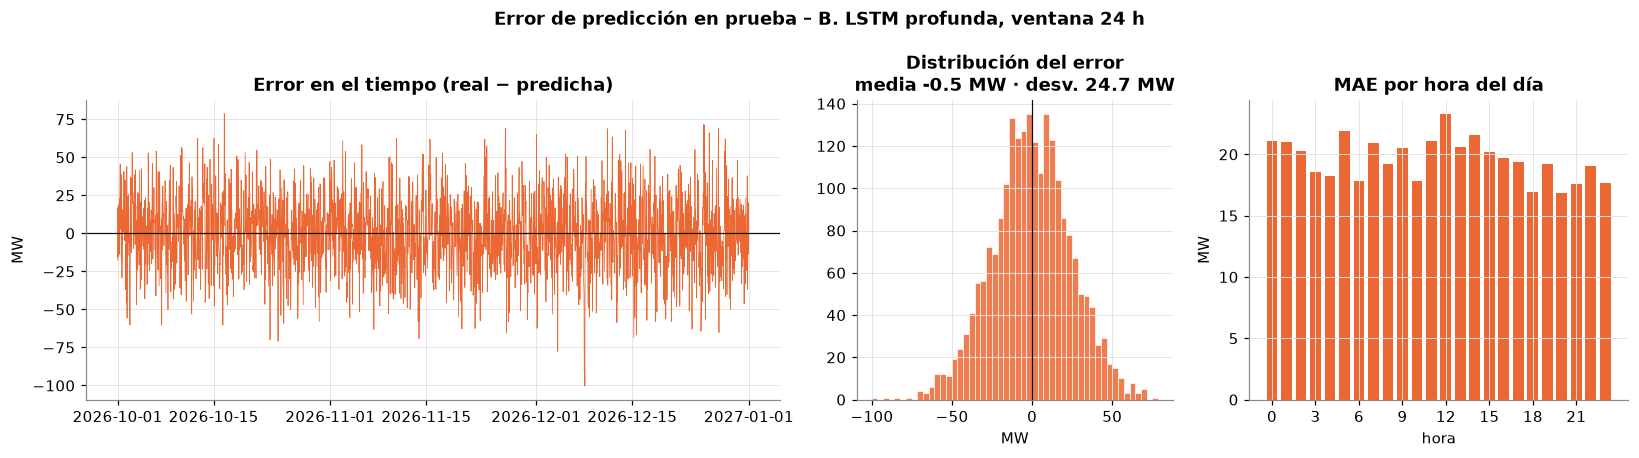

MAE en horas festivas: 30.7 MW | en horas no festivas: 19.3 MW


In [16]:
errors = y_true_best - y_pred_best
test_hours = best_test_times.hour
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), gridspec_kw={"width_ratios": [2.2, 1, 1.2]})
axes[0].plot(best_test_times, errors, color=ARCH_COLORS[best_arch], linewidth=0.5)
axes[0].axhline(0, color=COLOR_INK, linewidth=0.8)
axes[0].set_title("Error en el tiempo (real − predicha)")
axes[0].set_ylabel("MW")
axes[1].hist(errors, bins=50, color=ARCH_COLORS[best_arch], alpha=0.85, edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color=COLOR_INK, linewidth=0.8)
axes[1].set_title(f"Distribución del error\nmedia {errors.mean():.1f} MW · desv. {errors.std():.1f} MW")
axes[1].set_xlabel("MW")
mae_by_hour = pd.Series(np.abs(errors)).groupby(test_hours).mean()
axes[2].bar(mae_by_hour.index, mae_by_hour.values, color=ARCH_COLORS[best_arch], width=0.75)
axes[2].set_title("MAE por hora del día")
axes[2].set_xlabel("hora")
axes[2].set_ylabel("MW")
axes[2].set_xticks(range(0, 24, 3))
fig.suptitle(f"Error de predicción en prueba – {best_label}, ventana {best_window} h", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "prediction_error_best.png", bbox_inches="tight")
plt.show()

holiday_test = data.set_index("timestamp")["festivo"].reindex(best_test_times).to_numpy() == 1
print(f"MAE en horas festivas: {np.abs(errors[holiday_test]).mean():.1f} MW | "
      f"en horas no festivas: {np.abs(errors[~holiday_test]).mean():.1f} MW")

### 10.4 Comparación de modelos

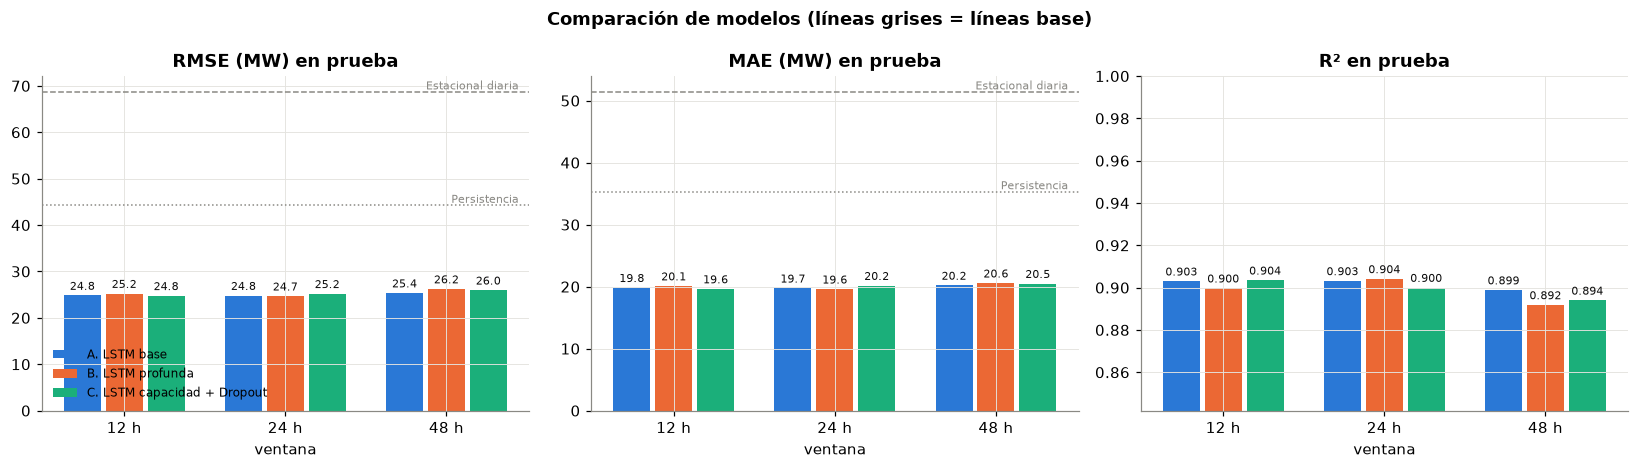

In [17]:
test_metrics = evaluation[evaluation["conjunto"] == "test"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
bar_width = 0.26
positions = np.arange(len(WINDOWS))
for ax, metric, unit in zip(axes, ["RMSE", "MAE", "R2"], ["MW", "MW", ""]):
    for offset, (arch_key, arch) in zip([-bar_width, 0, bar_width], ARCHITECTURES.items()):
        values = test_metrics[test_metrics["arch"] == arch_key].set_index("Ventana").loc[WINDOWS, metric]
        bars = ax.bar(positions + offset, values, width=bar_width - 0.03, color=ARCH_COLORS[arch_key], label=arch["label"])
        ax.bar_label(bars, labels=[f"{value:.3f}" if metric == "R2" else f"{value:.1f}" for value in values],
                     fontsize=7, padding=2, color=COLOR_INK)
    if metric != "R2":
        for (name, row), style in zip(baseline_results.iterrows(), [":", "--"]):
            ax.axhline(row[metric], color=COLOR_MUTED, linestyle=style, linewidth=1)
            ax.text(positions[-1] + 0.45, row[metric], name.split(" (")[0], fontsize=7, color=COLOR_MUTED,
                    va="bottom", ha="right")
    else:
        low = test_metrics["R2"].min()
        ax.set_ylim(max(0, low - 0.05), 1)
    ax.set_xticks(positions, [f"{window} h" for window in WINDOWS])
    ax.set_xlabel("ventana")
    ax.set_title(f"{'R²' if metric == 'R2' else metric}{' (' + unit + ')' if unit else ''} en prueba")
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
fig.suptitle("Comparación de modelos (líneas grises = líneas base)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()

## 11. Análisis de sobreajuste y generalización

Se compara el error en entrenamiento, validación y prueba. Si el error de entrenamiento fuera mucho menor que el de validación/prueba, el modelo estaría memorizando el entrenamiento (sobreajuste).

`brecha val/train` = RMSE validación ÷ RMSE entrenamiento. Valores cercanos a 1 indican buena generalización.

In [18]:
rmse_by_subset = evaluation.pivot_table(index=["Modelo", "Ventana"], columns="conjunto", values="RMSE")[["train", "val", "test"]]
rmse_by_subset["brecha val/train"] = rmse_by_subset["val"] / rmse_by_subset["train"]
rmse_by_subset["brecha test/train"] = rmse_by_subset["test"] / rmse_by_subset["train"]
rmse_by_subset.round(3)

conjunto                              train     val    test  brecha val/train  brecha test/train
Modelo                      Ventana                                                             
A. LSTM base                12       24.348  25.425  24.826             1.044              1.020
                            24       24.583  25.450  24.806             1.035              1.009
                            48       24.333  25.675  25.354             1.055              1.042
B. LSTM profunda            12       24.743  25.462  25.244             1.029              1.020
                            24       24.405  25.285  24.683             1.036              1.011
                            48       25.650  25.869  26.220             1.009              1.022
C. LSTM capacidad + Dropout 12       24.742  25.546  24.767             1.032              1.001
                            24       24.586  25.564  25.207             1.040              1.025
                            48       25.254  25.910  25.959             1.026              1.028

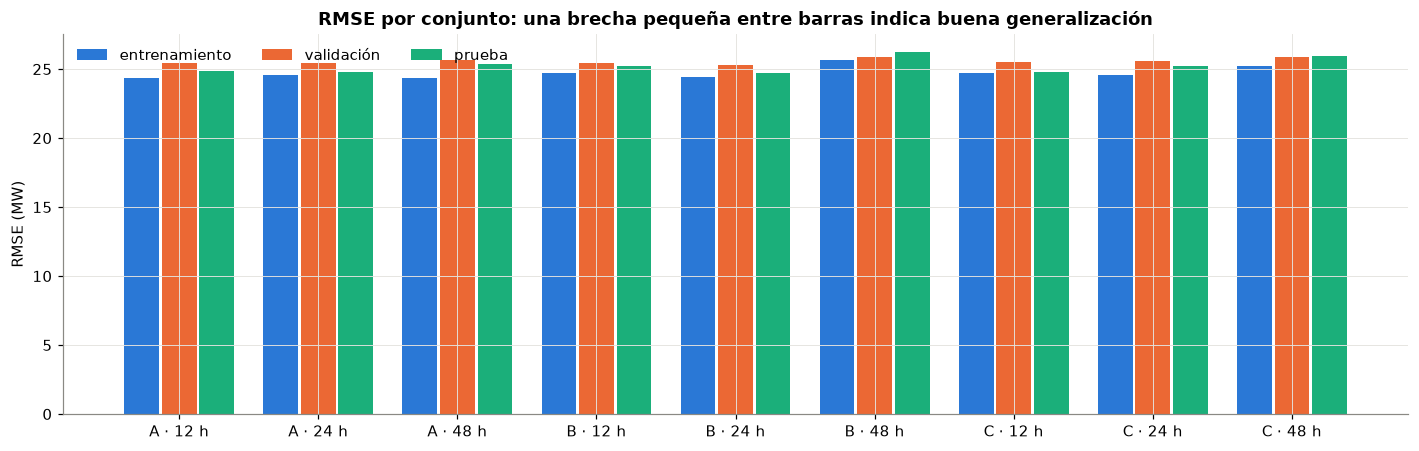

In [19]:
fig, ax = plt.subplots(figsize=(13, 4.2))
labels = [f"{model.split('. ')[0]} · {window} h" for model, window in rmse_by_subset.index]
x_positions = np.arange(len(labels))
for offset, subset, label in zip([-0.27, 0, 0.27], ["train", "val", "test"], ["entrenamiento", "validación", "prueba"]):
    ax.bar(x_positions + offset, rmse_by_subset[subset], width=0.25, color=SPLIT_COLORS[subset], label=label)
ax.set_xticks(x_positions, labels)
ax.set_ylabel("RMSE (MW)")
ax.set_title("RMSE por conjunto: una brecha pequeña entre barras indica buena generalización")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / "overfitting_rmse_by_subset.png", bbox_inches="tight")
plt.show()

## 12. Experimentos complementarios (para responder las preguntas 4, 5 y 6)

Todos con ventana de 24 h, las mismas capas (LSTM, Dense, Dropout) y la misma configuración de entrenamiento.

- **Neuronas:** arquitectura A con 16, 32, 64 (modelo principal), 128 y 256 unidades.
- **Dropout:** arquitectura C con dropout 0.0, 0.2 (modelo principal) y 0.4.
- **Early stopping:** arquitectura C **sin dropout** entrenada 100 épocas **sin early stopping**, para observar qué pasa si no se detiene el entrenamiento.

In [20]:
EXPERIMENT_WINDOW = 24
experiment_rows = []


def evaluate_experiment(experiment, setting, model, history):
    split = datasets[EXPERIMENT_WINDOW]
    row = {"experimento": experiment, "configuración": setting, "Parámetros": model.count_params(),
           "Épocas": len(history["loss"]), "Mejor época": early_stopping_trace(history["val_loss"])[0]}
    for subset in ("train", "val", "test"):
        y_pred = to_mw(model.predict(split[f"X_{subset}"], batch_size=512, verbose=0))
        row[f"RMSE {subset}"] = np.sqrt(mean_squared_error(to_mw(split[f"y_{subset}"]), y_pred))
    experiment_rows.append(row)


for units in [16, 32, 64, 128, 256]:
    if units == 64:
        model, history = models[("A", EXPERIMENT_WINDOW)], histories[("A", EXPERIMENT_WINDOW)]
    else:
        model, history = train_or_load(f"exp_units{units}_w{EXPERIMENT_WINDOW}",
                                       lambda window, n_features, units=units: build_lstm_base(window, n_features, units),
                                       EXPERIMENT_WINDOW)
    evaluate_experiment("Neuronas (LSTM base)", f"{units} unidades", model, history)

dropout_histories = {}
for dropout in [0.0, 0.2, 0.4]:
    if dropout == 0.2:
        model, history = models[("C", EXPERIMENT_WINDOW)], histories[("C", EXPERIMENT_WINDOW)]
    else:
        model, history = train_or_load(f"exp_dropout{int(dropout * 10)}_w{EXPERIMENT_WINDOW}",
                                       lambda window, n_features, dropout=dropout: build_lstm_regularized(window, n_features, dropout),
                                       EXPERIMENT_WINDOW)
    dropout_histories[dropout] = history
    evaluate_experiment("Dropout (arquitectura C)", f"dropout {dropout}", model, history)

no_es_model, no_es_history = train_or_load(f"exp_no_early_stopping_w{EXPERIMENT_WINDOW}",
                                           lambda window, n_features: build_lstm_regularized(window, n_features, 0.0),
                                           EXPERIMENT_WINDOW, epochs=MAX_EPOCHS, use_early_stopping=False)
evaluate_experiment("Sin early stopping", f"arquitectura C, dropout 0.0, {MAX_EPOCHS} épocas", no_es_model, no_es_history)

experiments = pd.DataFrame(experiment_rows)
experiments["brecha val/train"] = experiments["RMSE val"] / experiments["RMSE train"]
experiments.to_csv(REPORT_DIR / "complementary_experiments.csv", index=False, encoding="utf-8")
experiments.round(3)

,experimento,configuración,Parámetros,Épocas,Mejor época,RMSE train,RMSE val,RMSE test,brecha val/train
0,Neuronas (LSTM base),16 unidades,2065,53,43,24.393,25.470,24.656,1.044
1,Neuronas (LSTM base),32 unidades,6177,38,28,24.260,25.536,25.184,1.053
2,Neuronas (LSTM base),64 unidades,20545,23,13,24.583,25.450,24.806,1.035
3,Neuronas (LSTM base),128 unidades,73857,27,17,24.303,25.435,25.057,1.047
4,Neuronas (LSTM base),256 unidades,278785,27,17,24.556,25.733,25.133,1.048
5,Dropout (arquitectura C),dropout 0.0,125249,29,19,24.413,25.970,25.676,1.064
6,Dropout (arquitectura C),dropout 0.2,125249,30,20,24.586,25.564,25.207,1.040
7,Dropout (arquitectura C),dropout 0.4,125249,35,25,24.552,25.488,24.886,1.038
8,Sin early stopping,"arquitectura C, dropout 0.0, 100 épocas",125249,100,19,21.227,33.999,36.899,1.602


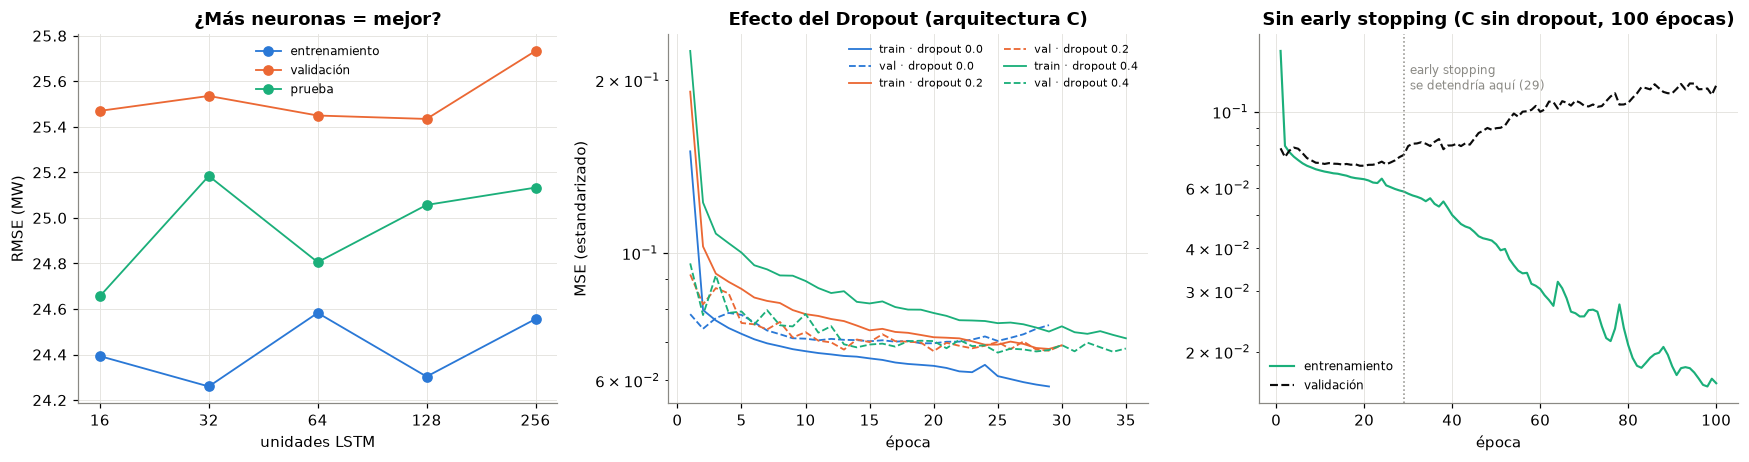

Sin early stopping: mejor val_loss en la época 19 (0.0697); val_loss final (época 100): 0.1194 → 71 % peor que el mejor punto.
Early stopping (paciencia 10) se habría detenido en la época 29 y restaurado los pesos de la época 19.


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
units_rows = experiments[experiments["experimento"].str.startswith("Neuronas")]
unit_counts = units_rows["configuración"].str.split().str[0].astype(int)
for subset, color, label in [("train", SPLIT_COLORS["train"], "entrenamiento"), ("val", SPLIT_COLORS["val"], "validación"),
                             ("test", SPLIT_COLORS["test"], "prueba")]:
    axes[0].plot(unit_counts, units_rows[f"RMSE {subset}"], marker="o", markersize=6, color=color, label=label)
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(unit_counts, [str(units) for units in unit_counts])
axes[0].set_xlabel("unidades LSTM")
axes[0].set_ylabel("RMSE (MW)")
axes[0].set_title("¿Más neuronas = mejor?")
axes[0].legend(frameon=False, fontsize=8)

for dropout, color in zip([0.0, 0.2, 0.4], ARCH_COLORS.values()):
    history = dropout_histories[dropout]
    epochs_axis = np.arange(1, len(history["loss"]) + 1)
    axes[1].plot(epochs_axis, history["loss"], color=color, linewidth=1.2, label=f"train · dropout {dropout}")
    axes[1].plot(epochs_axis, history["val_loss"], color=color, linewidth=1.2, linestyle="--", label=f"val · dropout {dropout}")
axes[1].set_yscale("log")
axes[1].set_xlabel("época")
axes[1].set_ylabel("MSE (estandarizado)")
axes[1].set_title("Efecto del Dropout (arquitectura C)")
axes[1].legend(frameon=False, fontsize=7, ncol=2)

epochs_axis = np.arange(1, len(no_es_history["loss"]) + 1)
val_curve = np.array(no_es_history["val_loss"])
would_restore, would_stop = early_stopping_trace(val_curve)
best_epoch_no_es = int(np.argmin(val_curve)) + 1
axes[2].plot(epochs_axis, no_es_history["loss"], color=ARCH_COLORS["C"], linewidth=1.4, label="entrenamiento")
axes[2].plot(epochs_axis, val_curve, color=COLOR_INK, linewidth=1.4, linestyle="--", label="validación")
axes[2].axvline(would_stop, color=COLOR_MUTED, linestyle=":", linewidth=1)
axes[2].annotate(f"early stopping\nse detendría aquí ({would_stop})", xy=(would_stop, 0.85), xycoords=("data", "axes fraction"),
                 fontsize=8, color=COLOR_MUTED, xytext=(4, 0), textcoords="offset points")
axes[2].set_yscale("log")
axes[2].set_xlabel("época")
axes[2].set_title(f"Sin early stopping (C sin dropout, {MAX_EPOCHS} épocas)")
axes[2].legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig(FIG_DIR / "complementary_experiments.png", bbox_inches="tight")
plt.show()

print(f"Sin early stopping: mejor val_loss en la época {best_epoch_no_es} ({val_curve.min():.4f}); "
      f"val_loss final (época {len(val_curve)}): {val_curve[-1]:.4f} → "
      f"{(val_curve[-1] / val_curve.min() - 1) * 100:.0f} % peor que el mejor punto.")
print(f"Early stopping (paciencia {EARLY_STOPPING_PATIENCE}) se habría detenido en la época {would_stop} "
      f"y restaurado los pesos de la época {would_restore}.")

## 13. ¿Qué variables influyen más?

**Importancia por permutación** (sobre prueba, mejor modelo): se desordena una variable entre muestras (rompiendo su relación con el target, pero conservando su distribución) y se mide cuánto empeora el RMSE. Cuanto más empeora, más depende el modelo de esa variable. Las parejas seno/coseno se permutan juntas.

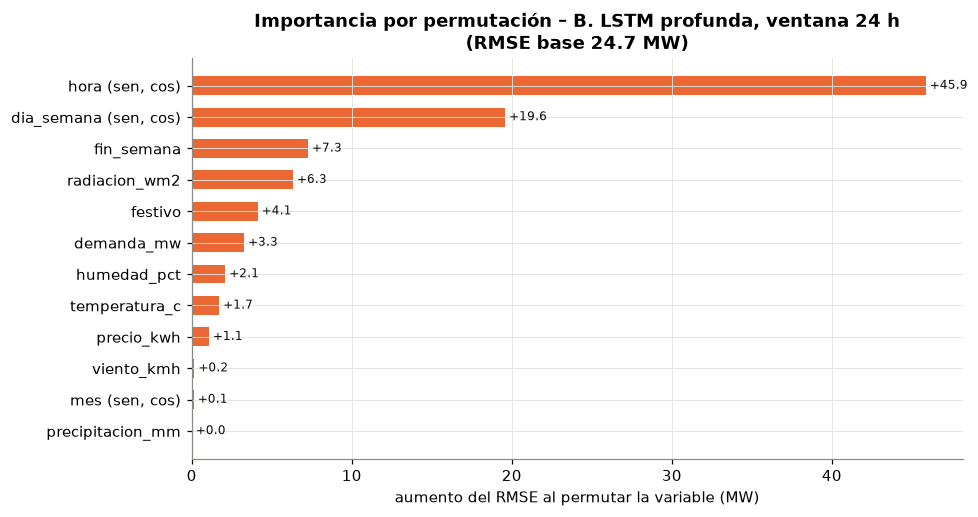

In [22]:
FEATURE_GROUPS = {
    "demanda_mw": ["demanda_mw"], "temperatura_c": ["temperatura_c"], "humedad_pct": ["humedad_pct"],
    "viento_kmh": ["viento_kmh"], "radiacion_wm2": ["radiacion_wm2"], "precipitacion_mm": ["precipitacion_mm"],
    "precio_kwh": ["precio_kwh"], "fin_semana": ["fin_semana"], "festivo": ["festivo"],
    "hora (sen, cos)": ["hora_sin", "hora_cos"], "dia_semana (sen, cos)": ["dia_sin", "dia_cos"],
    "mes (sen, cos)": ["mes_sin", "mes_cos"],
}
best_model = models[(best_arch, best_window)]
X_test_best = datasets[best_window]["X_test"]
y_test_best = to_mw(datasets[best_window]["y_test"])
base_rmse = np.sqrt(mean_squared_error(y_test_best, to_mw(best_model.predict(X_test_best, batch_size=512, verbose=0))))
rng = np.random.default_rng(SEED)
importance = {}
for group, columns in FEATURE_GROUPS.items():
    column_idx = [pipeline.FEATURE_COLS.index(column) for column in columns]
    increases = []
    for _ in range(3):
        permuted = X_test_best.copy()
        order = rng.permutation(len(permuted))
        permuted[:, :, column_idx] = X_test_best[order][:, :, column_idx]
        permuted_rmse = np.sqrt(mean_squared_error(y_test_best, to_mw(best_model.predict(permuted, batch_size=512, verbose=0))))
        increases.append(permuted_rmse - base_rmse)
    importance[group] = np.mean(increases)
importance = pd.Series(importance).sort_values()
importance.to_csv(REPORT_DIR / "permutation_importance.csv", header=["aumento_rmse_mw"], encoding="utf-8")

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(importance.index, importance.values, color=ARCH_COLORS[best_arch], height=0.6)
for y_pos, value in enumerate(importance.values):
    ax.text(value, y_pos, f" +{value:.1f}", va="center", fontsize=8, color=COLOR_INK)
ax.set_xlabel("aumento del RMSE al permutar la variable (MW)")
ax.set_title(f"Importancia por permutación – {best_label}, ventana {best_window} h\n(RMSE base {base_rmse:.1f} MW)")
fig.tight_layout()
fig.savefig(FIG_DIR / "permutation_importance.png", bbox_inches="tight")
plt.show()

## 14. Guardar artefactos para el despliegue

In [23]:
pipeline.save_preprocessing(feature_scaler, target_scaler, extra_config={
    "best_model": {"arch": best_arch, "label": best_label, "window": int(best_window),
                   "file": f"{ARCHITECTURES[best_arch]['slug']}_w{best_window}.keras"},
    "models": [{"arch": arch_key, "label": ARCHITECTURES[arch_key]["label"], "window": int(window),
                "file": f"{ARCHITECTURES[arch_key]['slug']}_w{window}.keras"}
               for arch_key in ARCHITECTURES for window in WINDOWS],
})
print("Guardado:", pipeline.SCALERS_PATH, "y", pipeline.CONFIG_PATH)
print("Modelos:", sorted(path.name for path in MODELS_DIR.glob("*.keras") if not path.name.startswith("exp_")))

Guardado: models\scalers.joblib y models\pipeline_config.json
Modelos: ['lstm_base_w12.keras', 'lstm_base_w24.keras', 'lstm_base_w48.keras', 'lstm_deep_w12.keras', 'lstm_deep_w24.keras', 'lstm_deep_w48.keras', 'lstm_regularized_w12.keras', 'lstm_regularized_w24.keras', 'lstm_regularized_w48.keras']


## 15. Respuestas a las preguntas de análisis

### 1. ¿Por qué LSTM es apropiada para este problema?

- **La demanda es una secuencia con memoria:** el valor de la próxima hora depende de lo que pasó en las horas anteriores (la rampa de la mañana, el pico de la tarde, si viene subiendo o bajando). Una LSTM procesa la ventana **hora por hora, en orden**, y mantiene un estado interno que resume ese historial.
- **Sus compuertas (olvido, entrada y salida)** deciden qué guardar y qué descartar del pasado. Esto evita el problema del gradiente que se desvanece de las RNN simples y le permite aprender dependencias de varias horas.
- **Es multivariada:** en cada hora recibe a la vez demanda, clima, precio y calendario, y aprende relaciones **no lineales** entre ellas (por ejemplo, la radiación solo importa de día).
- **Evidencia:** la mejor LSTM obtiene un RMSE de **24.7 MW** frente a **44.2 MW** de la persistencia (repetir la demanda actual): un **44 % menos de error**. El R² sube de 0.69 a 0.90.

### 2. ¿Qué efecto tiene cambiar la ventana temporal?

| Ventana | RMSE prueba A / B / C (MW) | Tiempo de entrenamiento A / B / C |
|---|---|---|
| 12 h | 24.8 / 25.2 / 24.8 | 26 s / 30 s / 60 s |
| 24 h | 24.8 / **24.7** / 25.2 | 33 s / 60 s / 120 s |
| 48 h | 25.4 / 26.2 / 26.0 | 85 s / 60 s / 176 s |

- **12 h y 24 h dan prácticamente el mismo error**, y **48 h es la peor en las tres arquitecturas** (entre 0.5 y 1.5 MW más de RMSE).
- Una ventana más larga aporta más contexto, pero también tiene costos: más pasos por los que propagar el gradiente (más difícil de optimizar) y hasta **3 veces más tiempo de cómputo**.
- En este dataset, la información útil está en las últimas horas y en el **calendario**. Como la hora del día ya entra como variable, el modelo no necesita ver 24 o 48 horas de historia para saber en qué parte del ciclo diario está.
- **Conclusión:** más ventana no es mejor por defecto. Aquí 12–24 h es el punto de equilibrio entre información y facilidad de entrenamiento.

### 3. ¿Existe sobreajuste?

**En los 9 modelos finales, no de forma significativa** (§11):

- El RMSE de validación es solo **1–6 % mayor** que el de entrenamiento (brecha val/train entre 1.01 y 1.06), y el de prueba es muy parecido al de validación.
- En las curvas de pérdida (§10.1), la validación se estabiliza y el **Early Stopping** corta el entrenamiento antes de que empiece a subir.

**Pero el riesgo sí existe:** el experimento sin Early Stopping (§12) lo demuestra. La arquitectura C sin Dropout, entrenada 100 épocas, llega a un RMSE de entrenamiento de **21.2 MW** (mejor que cualquier modelo), mientras que en validación sube a **34.0 MW** y en prueba a **36.9 MW**. Su `val_loss` final es **71 % peor** que en su mejor época (la 19). Es sobreajuste clásico: el modelo memoriza el ruido del entrenamiento y deja de generalizar.

### 4. ¿Qué es y qué efecto tiene Dropout?

**Qué es:** una técnica de regularización. En cada paso de entrenamiento **apaga al azar** una fracción de las salidas de una capa (20 % con `Dropout(0.2)`), así que la red no puede depender de neuronas específicas y debe aprender representaciones más generales. **Solo actúa durante el entrenamiento;** al predecir se usan todas las neuronas.

**Efecto medido** (arquitectura C, ventana 24 h):

| Dropout | RMSE train | RMSE validación | RMSE prueba | Brecha val/train |
|---|---|---|---|---|
| 0.0 | 24.4 | 26.0 | 25.7 | 1.064 |
| 0.2 | 24.6 | 25.6 | 25.2 | 1.040 |
| 0.4 | 24.6 | 25.5 | 24.9 | 1.038 |

- Con Dropout el error en validación y prueba **baja** y la brecha con entrenamiento **se reduce**: generaliza mejor.
- En las curvas (§12) la pérdida de entrenamiento con Dropout queda **por encima** de la de validación. No es un error: durante el entrenamiento la red trabaja "con neuronas apagadas" y se le hace más difícil, mientras que al validar las usa todas.
- El efecto es moderado porque, con Early Stopping, este modelo casi no sobreajustaba. Dropout es más importante en el modelo más grande (C, 125 000 parámetros).

### 5. ¿Qué es y qué efecto tiene Early Stopping?

**Qué es:** un criterio para **detener el entrenamiento automáticamente**. Tras cada época mide el error en validación; si pasan *paciencia* épocas (aquí 10) sin mejorar, se detiene y **restaura los pesos de la mejor época**.

**Efecto:**

- **Evita el sobreajuste.** En el experimento de §12 habría detenido el entrenamiento en la época 29 y conservado los pesos de la época 19 (`val_loss` 0.070), en vez de terminar en la época 100 con `val_loss` 0.119 (71 % peor) y un RMSE de prueba de 36.9 MW en lugar de ~25.7 MW.
- **Ahorra tiempo:** los 9 modelos se detuvieron entre la época 17 y la 32 de un máximo de 100.
- **Elimina la necesidad de adivinar el número de épocas:** cada modelo entrena lo que necesita.

### 6. ¿Más neuronas implican necesariamente mejores resultados?

**No.** El experimento de §12 (arquitectura A, ventana 24 h) lo muestra:

| Unidades LSTM | Parámetros | RMSE validación | RMSE prueba |
|---|---|---|---|
| 16 | 2 065 | 25.5 | 24.7 |
| 64 | 20 545 | 25.5 | 24.8 |
| 256 | 278 785 | 25.7 | 25.1 |

Con **135 veces más parámetros**, el modelo de 256 unidades es ligeramente **peor**, entrena unas 5 veces más lento y tiene más riesgo de sobreajuste. Lo mismo pasa entre arquitecturas: C (125 000 parámetros) no supera a A (20 500).

**Por qué:** todos los modelos llegan al mismo "piso" de error, ~24–25 MW, que es también su error en **entrenamiento**. Ese piso corresponde a la variabilidad aleatoria de la demanda hora a hora, que ninguna variable del dataset explica (ruido irreducible). Cuando el error está limitado por los datos y no por la capacidad del modelo, añadir neuronas no ayuda. La capacidad debe ajustarse a la complejidad del problema y a la cantidad de datos.

### 7. ¿Qué modelo recomendaría para producción y por qué?

**B. LSTM profunda con ventana de 24 h** (MAE 19.6 MW, RMSE 24.7 MW, MAPE 3.36 %, R² 0.904 en prueba):

- **Fue el mejor en validación**, que es el criterio de selección correcto (el conjunto de prueba solo se usa para confirmar). Además también es el mejor en prueba, así que la elección es consistente.
- **Generaliza bien:** brecha val/train de 1.04, sin señales de sobreajuste.
- **Es ligero:** 33 000 parámetros, se entrena en ~1 minuto y predice en milisegundos, lo que facilita reentrenarlo con frecuencia.
- **24 h es una ventana natural para la operación:** el día completo anterior.

Las diferencias con A (12 o 24 h) y con C (12 h) son menores de 0.5 MW, dentro del margen de variación entre entrenamientos. **A con 24 h** sería una alternativa igual de válida si se prioriza la máxima simplicidad (20 500 parámetros). **No se recomienda C** (4 veces más parámetros sin ganancia) **ni la ventana de 48 h** (peor y 2–3 veces más lenta). Este es el modelo que usa por defecto la app web.

### 8. ¿Qué variables pueden influir más en la demanda?

Según la **importancia por permutación** (§13: cuánto empeora el RMSE si se desordena la variable):

1. **Hora del día** (+45.9 MW): de lejos la más importante, por el ciclo diario (madrugada baja, picos de mañana y noche).
2. **Día de la semana** (+19.6 MW) y **fin de semana** (+7.3 MW): la actividad laboral cambia el nivel de consumo.
3. **Radiación solar** (+6.3 MW): indica las horas de luz y se relaciona con el consumo diurno.
4. **Festivo** (+4.1 MW): un festivo se comporta como un domingo.
5. **Demanda reciente** (+3.3 MW), **humedad** (+2.1) y **temperatura** (+1.7): ajustan el nivel según el clima y la inercia de la serie.
6. **Precio, viento, mes y precipitación** (< 1.1 MW): aportan poco una vez que se conocen las anteriores.

**Matiz:** si dos variables comparten información, permutar una sola subestima su importancia, porque la otra la compensa. La demanda reciente y la temperatura, por ejemplo, están correlacionadas con la hora y la estación. Por eso su importancia individual parece baja, aunque son relevantes.

### 9. ¿Qué limitaciones tiene el modelo?

- **Solo predice una hora adelante.** Para planificar el día siguiente habría que predecir de forma recursiva (con acumulación de error) o entrenar un modelo multi-paso.
- **Necesita las variables observadas hasta la hora actual.** En producción la medición del clima puede llegar tarde o con fallas; el *forward fill* de la limpieza es una solución simple, pero no ideal para huecos largos.
- **Festivos:** el error en horas festivas es mayor (MAE 30.7 MW frente a 19.3 MW en días normales), porque hay muy pocos festivos para aprender (12 días en dos años).
- **Piso de error de ~25 MW:** ninguna arquitectura baja de ahí; mejorar exigiría nuevas variables (eventos, actividad industrial, pronósticos meteorológicos), no un modelo más grande.
- **Solo dos años de datos:** el modelo vio apenas 1.5 ciclos anuales en entrenamiento y no conoce situaciones fuera de ese rango (olas de calor extremas, cambios estructurales de consumo). Las predicciones en esos escenarios son extrapolaciones.
- **Deriva en el tiempo:** si el patrón de consumo cambia (nuevos clientes, tarifas, eficiencia energética), el modelo pierde precisión y debe **reentrenarse periódicamente**.
- **Interpretabilidad limitada:** una LSTM es una "caja negra"; la importancia por permutación da una idea global, pero no explica cada predicción individual.

## 16. Conclusiones

- Con datos limpios y una preparación correcta (split cronológico, normalización solo con entrenamiento, sin variables del futuro), **las tres arquitecturas LSTM predicen la demanda de la próxima hora con un error de ~3.4 %** (R² ≈ 0.90), y reducen el error de la persistencia en un 44 %.
- **La arquitectura importa poco en este problema:** los 9 modelos quedan dentro de 1.5 MW de RMSE entre sí. Pesan más la ventana (48 h empeora) y, sobre todo, la regularización: sin Early Stopping el error de prueba sube un 44 % (36.9 frente a 25.7 MW).
- **Modelo recomendado:** B. LSTM profunda con ventana de 24 h, desplegado en la app web (`streamlit run app.py`).